In [1]:
import pandas as pd
import hcrseq.amplicon.plotting as amp
import matplotlib.pyplot as plt
from scipy.stats import binom
from scipy.stats import poisson
import hcrseq
from hcrseq.amplicon.quantify import quantify_repair
import numpy as np
import seaborn as sns

In [2]:
pathway_info = hcrseq.__path__[0] + '/../reference/HCRseq_v0.3/pathway_calculations.txt'

In [3]:
def load_file(file):
    df = pd.read_csv(file)
    df[['cell_line','condition','timepoint','replicate']] = df['sample'].str.split('_',expand=True)
    df['timepoint'] = df['timepoint'].str.extract('(\d+)h').astype(float)
    
    return(df)

In [4]:
P = pd.read_csv(pathway_info,sep='\t')
P.head()

,pathway,metric,reporter
0,MMR,fraction_repaired,GFP_BAR_003
1,NER,abundance,GFP_BAR_004
2,DR_O6MeG,fraction_repaired,GFP_BAR_005
3,BER_8oxoG_C,fraction_repaired,GFP_BAR_006
4,BER_A_8oxoG,fraction_repaired,GFP_BAR_007


In [5]:
C = load_file('../data/final_merged_set.reporter_counts.csv')


In [6]:
C.head()

,Unnamed: 0,metric,reporter,count,sample,cell_line,condition,timepoint,replicate
0,0,A,GFP_BAR_003,1,U2OS_XPG_4h_BR3,U2OS,XPG,4.0,BR3
1,1,C,GFP_BAR_003,13240,U2OS_XPG_4h_BR3,U2OS,XPG,4.0,BR3
2,2,G,GFP_BAR_003,1820,U2OS_XPG_4h_BR3,U2OS,XPG,4.0,BR3
3,3,T,GFP_BAR_003,3,U2OS_XPG_4h_BR3,U2OS,XPG,4.0,BR3
4,4,del,GFP_BAR_003,2,U2OS_XPG_4h_BR3,U2OS,XPG,4.0,BR3


In [7]:
def downsample_counts(counts,N):
    tot = sum([v['total'] for k,v in counts.items()])
    
    counts_d = dict()
    
    for key in counts.keys():
        counts_d[key]=dict()
        for metric in counts[key].keys():
            counts_d[key][metric] = poisson.rvs(counts[key][metric] * N/tot)
    return(counts_d)
    
    

In [8]:
def run_downsampling_experiment(counts,min_umi,max_umi,nit,npoint=10):
    cov_range = 10.0**np.linspace(np.log10(min_umi),
                                  np.log10(max_umi),npoint)
    
    res = list()
    for N in cov_range:
        for it in range(0,nit):
            counts_d = downsample_counts(counts,N)
            r_d = quantify_repair(counts_d,pathway_info)
            for k,v in r_d.items():
                res.append(pd.Series({'pathway' : k,
                                  'N' : N,
                                  'value' : v['value'],'it' : it}))
    df = pd.concat(res,axis=1).T
    
    return(df)


In [9]:
pathway_map = {'XPG' : 'NER','MSH2' : 'MMR','MUTYH':'BER_A_8oxoG','OGG1' : 'BER_8oxoG_C','MGMT' : 'DR_O6MeG',
               'UNG' : 'BER_UG', 'MPG' : 'BER_Hx','LIG4' : 'NHEJ','PolQ' : 'MMEJ'}


In [10]:
dfs = list()
for cond,g in C.groupby('condition'):
    if cond=='WT':
        continue
        
    case = g['sample'].iloc[0]

    control_idx = (C['cell_line']==g['cell_line'].iloc[0])&(C['timepoint']==g['timepoint'].iloc[0])&(C['condition']=='WT')
    control = C.loc[control_idx,'sample'].iloc[0]

    counts = C[C['sample']==case].set_index(["reporter", "metric"])["count"].unstack().to_dict(orient="index")
    df = run_downsampling_experiment(counts,1000,100000,1000)
    df = df[df['pathway'] == pathway_map[cond]]
    df['type'] = 'KO'
    df['sample'] = case
    df['condition'] = cond

    dfs.append(df)


    counts = C[C['sample']==control].set_index(["reporter", "metric"])["count"].unstack().to_dict(orient="index")
    df = run_downsampling_experiment(counts,1000,100000,1000)

    df = df[df['pathway'] == pathway_map[cond]]
    df['type'] = 'WT'
    df['sample'] = control
    df['condition'] = cond

    dfs.append(df)
    

/Users/njharlen/git/HCRseq/hcrseq/amplicon/quantify.py:46: RuntimeWarning: invalid value encountered in sqrt
  sd = float(np.sqrt(1/control**2 * (reporter + r**2*control)))
/Users/njharlen/git/HCRseq/hcrseq/amplicon/quantify.py:46: RuntimeWarning: invalid value encountered in sqrt
  sd = float(np.sqrt(1/control**2 * (reporter + r**2*control)))
/Users/njharlen/git/HCRseq/hcrseq/amplicon/quantify.py:46: RuntimeWarning: invalid value encountered in sqrt
  sd = float(np.sqrt(1/control**2 * (reporter + r**2*control)))
/Users/njharlen/git/HCRseq/hcrseq/amplicon/quantify.py:46: RuntimeWarning: invalid value encountered in sqrt
  sd = float(np.sqrt(1/control**2 * (reporter + r**2*control)))
/Users/njharlen/git/HCRseq/hcrseq/amplicon/quantify.py:46: RuntimeWarning: invalid value encountered in sqrt
  sd = float(np.sqrt(1/control**2 * (reporter + r**2*control)))
/Users/njharlen/git/HCRseq/hcrseq/amplicon/quantify.py:46: RuntimeWarning: invalid value encountered in sqrt
  sd = float(np.sqrt(1/con

In [11]:
df = pd.concat(dfs,axis=0)

In [12]:
df['pathway'] = pd.Categorical(df['pathway'],['MMR','DR_O6MeG', 'BER_8oxoG_C','BER_A_8oxoG','BER_UG','BER_Hx',
         'NER','NHEJ','MMEJ'])

In [28]:
df['pathway'] = df['pathway'].cat.rename_categories({'DR_O6MeG' : 'DR (O6MeG)',
                      'BER_8oxoG_C' : 'BER (8oxoG:C)',
                      'BER_A_8oxoG' : 'BER (A:8oxoG)',
                      'BER_UG' : 'BER (U:G)',
                      'BER_Hx' : 'BER (Hx:T)'})

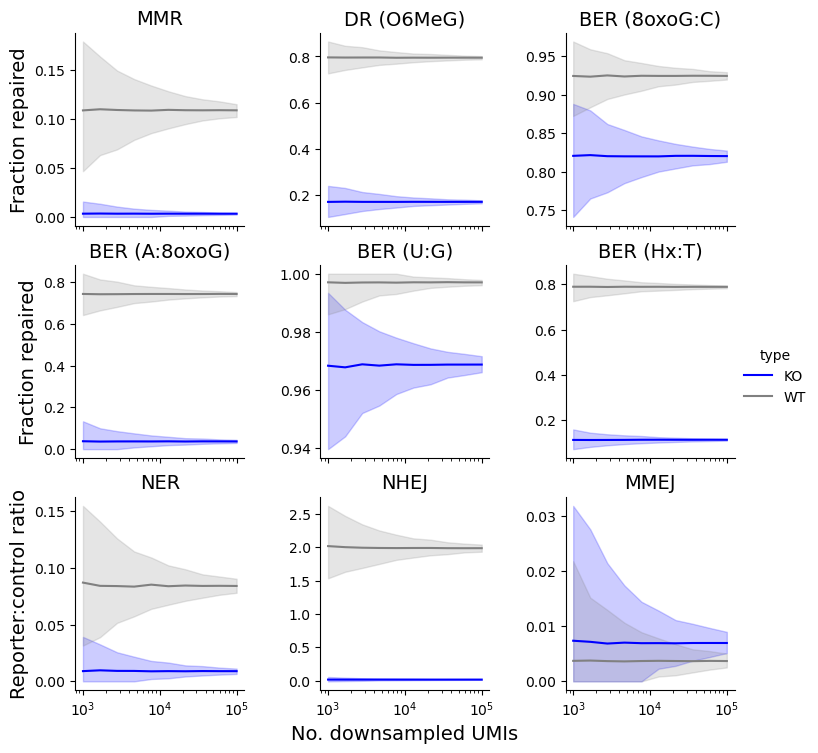

In [32]:
g = sns.relplot(x='N',y='value',col='pathway',hue='type',data=df,errorbar=('pi',95),kind='line',col_wrap=3,
                facet_kws={'sharey':False},height=2.5,palette = {'WT' : 'grey','KO' : 'blue'})

g.set(xscale="log")
g.set_titles(col_template="{col_name}", row_template="{row_name}",size=14)

g.axes[0].set_ylabel('Fraction repaired',fontsize=14)
g.axes[3].set_ylabel('Fraction repaired',fontsize=14)
g.axes[6].set_ylabel('Reporter:control ratio',fontsize=14)

g.axes[6].set_xlabel('')
g.axes[7].set_xlabel('No. downsampled UMIs',fontsize=14)
g.axes[8].set_xlabel('')

plt.savefig("pdf/figure2c_downsampling.pdf")